<a href="https://colab.research.google.com/github/fatimaezzahrabakas61-web/meteo_project/blob/main/visualisation_apports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def pipeline_visualisation_apports(file_path, colonne_date='Date', colonne_valeur='Apports'):
    """
    Pipeline complet de visualisation des apports (mensuel 1937–2022)

    Paramètres :
    file_path : chemin du fichier CSV
    colonne_date : nom de la colonne date (ex: 'Date')
    colonne_valeur : nom de la colonne des apports
    """

    # ---------------------------
    # 1. Chargement des données
    # ---------------------------
    df = pd.read_csv(file_path)

    # Make a copy for safe modifications
    df_processed = df.copy()

    # ---------------------------
    # 2. Date conversion and preparation for trend plots
    # ---------------------------
    date_col_for_trend = 'parsed_date_for_trend' # New column for datetime objects

    if colonne_date == 'years':
        # Assuming 'years' column has format 'YYYY-YYYY' (e.g., '1937-1938')
        # We'll use the start year and a fixed month (e.g., September) for time series plotting
        df_processed[date_col_for_trend] = df_processed[colonne_date].apply(
            lambda x: pd.to_datetime(x.split('-')[0] + '-09-01', errors='coerce') if isinstance(x, str) else pd.NaT
        )
    else:
        # For other date formats (like '09-1937'), use the original parsing logic
        df_processed[date_col_for_trend] = pd.to_datetime(df_processed[colonne_date], format='%m-%Y', errors='coerce')

    # Drop rows with NaT in the parsed date or NaN in the value column for trend plots
    df_trend = df_processed.dropna(subset=[date_col_for_trend, colonne_valeur]).sort_values(by=date_col_for_trend)

    if df_trend.empty:
        print("Warning: No data available for trend analysis after date parsing and cleaning.")
        # Cannot proceed with trend plots if df_trend is empty
    else:
        # ---------------------------
        # 3. Série temporelle
        # ---------------------------
        plt.figure()
        plt.plot(df_trend[date_col_for_trend], df_trend[colonne_valeur])
        plt.title("Évolution des apports (1937–2022)")
        plt.xlabel("Date")
        plt.ylabel("Apports")
        plt.grid()
        plt.show()

        # ---------------------------
        # 4. Moyenne mobile (12 mois)
        # ---------------------------
        df_trend['moyenne_mobile'] = df_trend[colonne_valeur].rolling(window=12, min_periods=1).mean() # min_periods to avoid all NaN at start

        plt.figure()
        plt.plot(df_trend[date_col_for_trend], df_trend['moyenne_mobile'], label="Moyenne mobile (12 mois)")
        plt.plot(df_trend[date_col_for_trend], df_trend[colonne_valeur], label="Original")
        plt.title("Tendance des apports")
        plt.xlabel("Date")
        plt.ylabel("Apports")
        plt.legend()
        plt.grid()
        plt.show()

    # ---------------------------
    # 5. Saisonnalité (par mois) - Adapted for wide-format monthly data
    # ---------------------------
    # Identify monthly columns from the original df (e.g., 'Sep', 'Oct', ...)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    # Filter for existing month columns in the original DataFrame
    existing_month_cols = [col for col in month_names if col in df.columns]

    if existing_month_cols:
        # Melt the DataFrame to transform monthly columns into rows
        df_melted = df.melt(id_vars=[colonne_date], value_vars=existing_month_cols,
                            var_name='Mois_Nom', value_name='Valeur_Mensuelle')

        # Map month names to month numbers for correct ordering on the plot
        month_name_to_num = {name: i+1 for i, name in enumerate(month_names)}
        df_melted['Mois_Num'] = df_melted['Mois_Nom'].map(month_name_to_num)

        # Drop rows with NaN in monthly values or month number
        df_season = df_melted.dropna(subset=['Valeur_Mensuelle', 'Mois_Num'])

        if not df_season.empty:
            plt.figure(figsize=(12, 6)) # Larger figure for better readability
            df_season.boxplot(column='Valeur_Mensuelle', by='Mois_Num')
            plt.title("Saisonnalité des apports par mois")
            plt.suptitle("") # Remove default suptitle
            plt.xlabel("Mois")
            plt.ylabel("Apports")
            # Set x-tick labels to month names for better readability
            # Ensure labels match the order of month numbers after mapping
            sorted_month_names = [name for num, name in sorted([(v, k) for k, v in month_name_to_num.items()]) if name in existing_month_cols]
            plt.xticks(ticks=range(1, len(sorted_month_names) + 1), labels=sorted_month_names, rotation=45, ha='right')
            plt.grid(axis='y')
            plt.tight_layout() # Adjust layout to prevent labels overlapping
            plt.show()
        else:
            print("Warning: No data available for monthly seasonality plot after melting and cleaning.")
    else:
        print("Warning: No monthly columns (Jan, Feb, ..., Dec) found in the DataFrame for seasonality analysis.")
        # Fallback for seasonality if monthly columns are not found but there's a 'mois' column from a valid date
        if not df_trend.empty and 'mois' in df_trend.columns:
            plt.figure()
            df_trend.boxplot(column=colonne_valeur, by='mois')
            plt.title("Saisonnalité des apports (from derived month)")
            plt.suptitle("")
            plt.xlabel("Mois")
            plt.ylabel("Apports")
            plt.show()

    # ---------------------------
    # 6. Distribution globale
    # ---------------------------
    # Use the original df_processed (after initial date parsing) for global distribution
    df_hist = df_processed.dropna(subset=[colonne_valeur])
    if not df_hist.empty:
        plt.figure()
        plt.hist(df_hist[colonne_valeur], bins=30) # Added bins for better visualization
        plt.title("Distribution des apports")
        plt.xlabel("Valeurs")
        plt.ylabel("Fréquence")
        plt.show()
    else:
        print(f"Warning: No valid data for '{colonne_valeur}' for global distribution plot. Skipping histogram.")

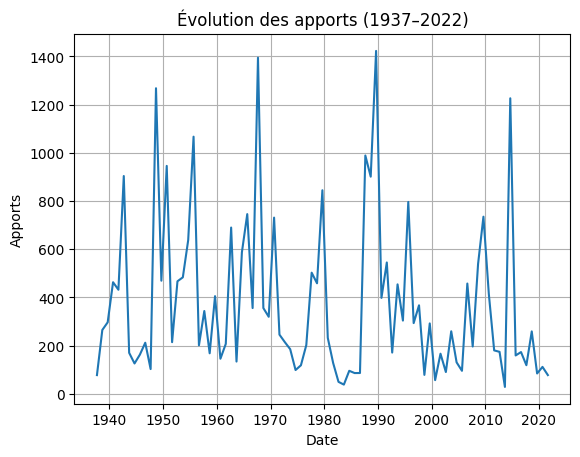

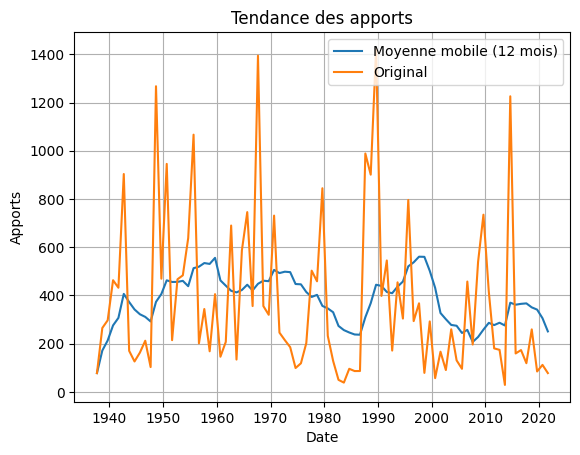

<Figure size 1200x600 with 0 Axes>

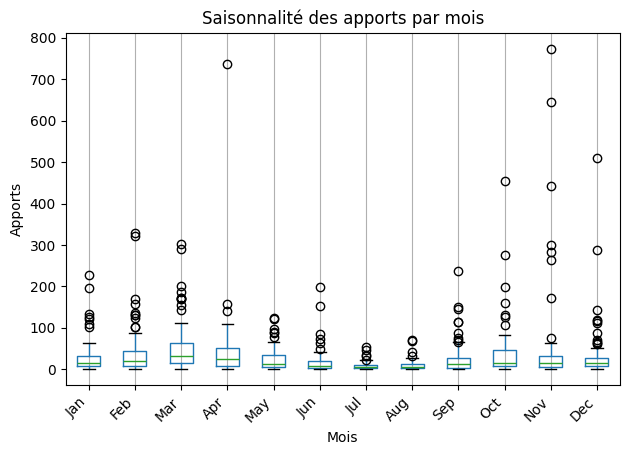

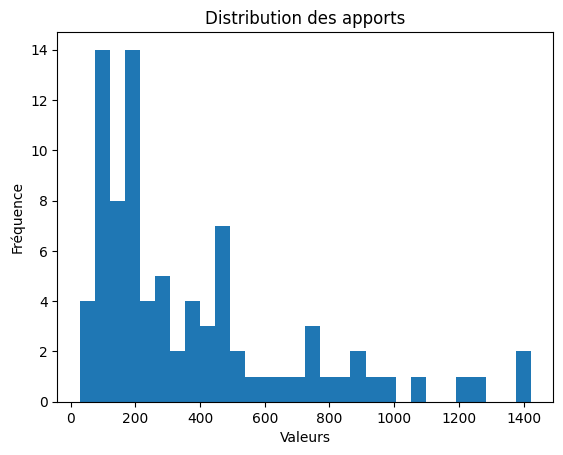

In [9]:
pipeline_visualisation_apports("dataset_Apports_clean_MED.csv", colonne_date='years', colonne_valeur='Total')